# 4 &middot; Distributed PM

JAX can shard array computations across several devices (GPUs/TPUs) with its
[sharding API](https://docs.jax.dev/en/latest/sharded-computation.html). `jax_fli` accepts an
optional `field_sharding` on `gaussian_initial_conditions` that partitions the initial field
across devices; **every** downstream operation (`lpt`, `nbody`, painting, halo exchange) then
respects it automatically &mdash; the pipeline code is identical to the single-device case.

This notebook runs on **8 GPU devices** 

## Setup

You can simulate multiple devices on a single CPU by setting the `XLA_FLAGS` environment variable to include `--xla_force_host_platform_device_count=8` (or however many devices you want). This forces JAX to treat the CPU as if it had multiple devices, allowing you to test distributed computations without needing actual GPUs.

The `--xla_force_host_platform_device_count` flag must be set **before** JAX initialises its backend (before the first `import jax`). 

```
import os
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=8"
os.environ["JAX_PLATFORMS"] = "cpu"
```

On real GPUs, drop both variables &mdash; JAX discovers the devices automatically.

In [1]:
import jax
import jax.numpy as jnp
import jax_cosmo as jc
import jax_fli as jfli
import matplotlib.pyplot as plt
import numpy as np
from jax.sharding import AxisType, NamedSharding
from jax.sharding import PartitionSpec as P

jax.config.update("jax_enable_x64", False)
print(f"Number of devices: {jax.device_count()}")
print(jax.devices())

JAX is not using 64-bit precision. This will dramatically affect numerical precision at even moderate L.


JAX is not using 64-bit precision. Results will diverge from healpy even at moderate nside and can overflow for nside > 8192. See the README on numerical precision.


Number of devices: 8
[CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7)]


## Device mesh and sharding

A `Mesh` maps physical devices onto named axes; a `PartitionSpec` then says which array
dimensions are split over which mesh axes. The `jaxpm` distributed backend expects a **2-D
mesh** so that the first two spatial dimensions of the 3-D field are each partitioned.

In [2]:
mesh = jax.make_mesh((8, 1), ("x", "y"), axis_types=(AxisType.Auto, AxisType.Auto))
sharding = NamedSharding(mesh, P("x", "y"))
print(f"Mesh shape     : {mesh.shape}")
print(f"Partition spec : {sharding.spec}")

Mesh shape     : OrderedDict({'x': 8, 'y': 1})
Partition spec : P('x', 'y')


## Distributed initial conditions

Pass `field_sharding` (and a `halo_size` of ghost cells for the stencil/FFT exchange) to
`gaussian_initial_conditions`. The returned field carries the sharding, so the rest of the
pipeline is unchanged.

In [3]:
key = jax.random.PRNGKey(0)
mesh_size = (512, 512, 512)
halo_size = (32, 32)
box_size = (1000.0, 1000.0, 1000.0)
nside = 512
flatsky_npix = (512, 512)
field_size = (10.0, 10.0)
cosmo = jc.Planck18()

initial_field = jfli.gaussian_initial_conditions(
    key,
    mesh_size,
    box_size,
    cosmo=cosmo,
    nside=nside,
    flatsky_npix=flatsky_npix,
    field_size=field_size,
    field_sharding=sharding,
    halo_size=halo_size,
)
print(f"shape    : {initial_field.array.shape}")
print(f"sharding : {initial_field.array.sharding}")

shape    : (64, 64, 64)
sharding : NamedSharding(mesh=Mesh('x': 8, 'y': 1, axis_types=(Auto, Auto)), spec=P('x',), memory_kind=device)


## Run the distributed pipeline

`lpt` and `nbody` are called exactly as on a single device. We visualise the sharding of
intermediate arrays with `jax.debug.visualize_array_sharding` (install `rich` for colour).

In [4]:
dx, p = jfli.lpt(cosmo, initial_field, ts=0.1, order=1)
print("displacement sharding:", dx.array.sharding)
jax.debug.visualize_array_sharding(dx.array[..., 0, 0])

displacement sharding: NamedSharding(mesh=Mesh('x': 8, 'y': 1, axis_types=(Auto, Auto)), spec=P('x',), memory_kind=device)


          CPU 0          
                         
          CPU 1          
                         
          CPU 2          
                         
          CPU 3          
                         
          CPU 4          
                         
          CPU 5          
                         
          CPU 6          
                         
          CPU 7          
                         

### Distributed lightcone painting

`nbody` builds a lightcone of `nb_shells` shells while the particles stay sharded. The solver
carries the integration window (`t0`, `t1`, `n_steps`); `t0` must match the LPT scale factor.
First a **flat-sky** lightcone:

In [5]:
solver_flat = jfli.DoubleKickDrift(
    interp_kernel=jfli.NoInterp(painting=jfli.PaintingOptions(target="flat")),
    t0=0.1,
    t1=1.0,
    n_steps=16,
)
flat_lc = jfli.nbody(cosmo, dx, p, nb_shells=4, solver=solver_flat).block_until_ready()
print(f"{type(flat_lc).__name__}  shape={flat_lc.shape}")
jax.debug.visualize_array_sharding(flat_lc.array[0])

FlatDensity  shape=(4, 64, 64)


          CPU 0          
                         
          CPU 1          
                         
          CPU 2          
                         
          CPU 3          
                         
          CPU 4          
                         
          CPU 5          
                         
          CPU 6          
                         
          CPU 7          
                         

and a **HEALPix** lightcone (the `ngp` scheme, ready for window deconvolution as in [notebook 2](../1-introduction-and-basics/02-LPT-Simulation.ipynb)):

In [6]:
solver_sph = jfli.DoubleKickDrift(
    interp_kernel=jfli.NoInterp(painting=jfli.PaintingOptions(target="spherical", scheme="ngp")),
    t0=0.1,
    t1=1.0,
    n_steps=16,
)
sph_lc = jfli.nbody(cosmo, dx, p, nb_shells=4, solver=solver_sph)
print(f"{type(sph_lc).__name__}  shape={sph_lc.shape}")
print("sharding:", sph_lc.array.sharding)
jax.debug.visualize_array_sharding(sph_lc.array[0])

SphericalDensity  shape=(4, 49152)
sharding: NamedSharding(mesh=Mesh('x': 8, 'y': 1, axis_types=(Auto, Auto)), spec=P(None, 'x'), memory_kind=device)


  CPU 0    CPU 1    CPU 2    CPU 3    CPU 4    CPU 5    CPU 6    CPU 7  
                                                                        

The four painted HEALPix shells (`SphericalDensity.show` gathers them for display):

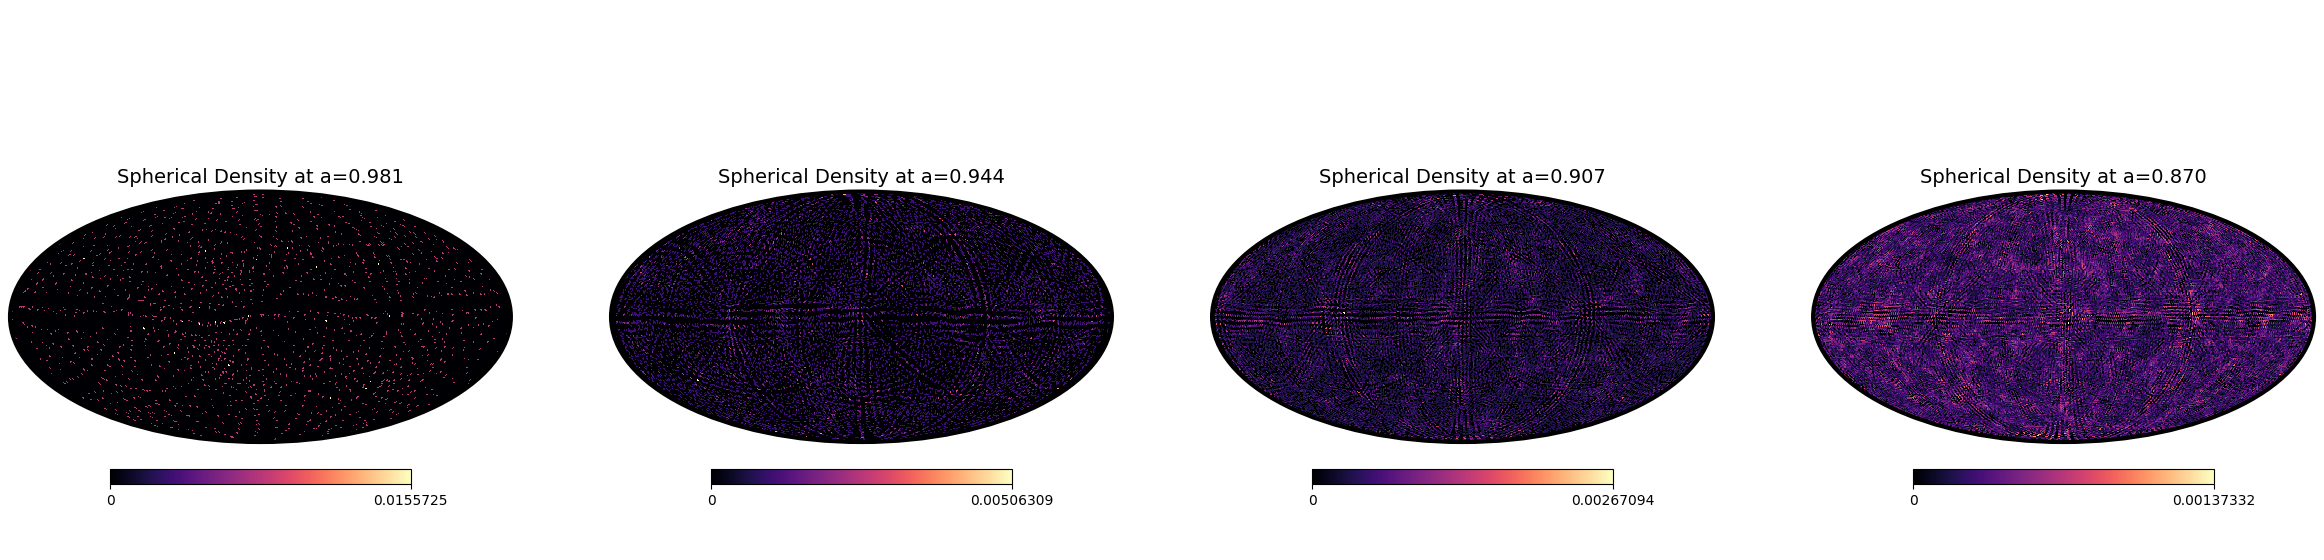

In [7]:
sph_lc.apply_fn(jnp.log1p).show(ncols=4)

## Distributed power spectrum: deconvolution + shot noise

The window-deconvolution and shot-noise corrections from
[notebook 3](../1-introduction-and-basics/03-PM-Simulation.ipynb) work **unchanged** on a
sharded field. We evolve one 3-D snapshot and measure $P(k)$ with and without the corrections.

> This is a deliberately large box at low resolution (to keep the distributed demo light), so it
> is strongly shot-noise dominated; the corrections apply identically &mdash; see notebook 3 for a
> quantitative match to Halofit.

DensityField  shape=(64, 64, 64)  sharding=NamedSharding(mesh=Mesh('x': 8, 'y': 1, axis_types=(Auto, Auto)), spec=P('x',), memory_kind=device)


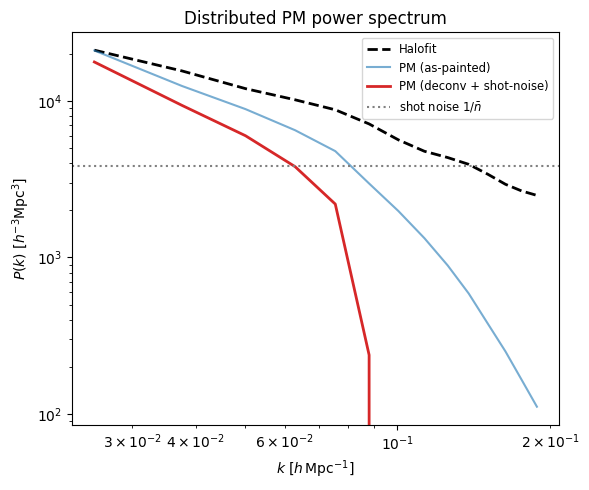

In [8]:
solver_box = jfli.DoubleKickDrift(
    interp_kernel=jfli.NoInterp(painting=jfli.PaintingOptions(target="density")),
    t0=0.1,
    t1=1.0,
    n_steps=16,
)
density = jfli.nbody(cosmo, dx, p, ts=jnp.array([1.0]), solver=solver_box)
print(f"{type(density).__name__}  shape={density.shape}  sharding={density.array.sharding}")

nbar = float(np.prod(mesh_size) / np.prod(box_size))
pk_raw = density.power()
pk_corr = density.power(compensate_order="cic", shotnoise=("cic", nbar))

k = np.asarray(pk_raw.wavenumber)
halofit = np.asarray(
    jax.jit(jc.power.nonlinear_matter_power, static_argnames=["nonlinear_fn"])(
        cosmo, jnp.asarray(k), a=1.0, nonlinear_fn=jc.power.halofit
    )
)

fig, ax = plt.subplots(figsize=(6, 5))
ax.loglog(k, halofit, "k--", lw=2, label="Halofit")
ax.loglog(k, np.asarray(pk_raw.array), color="C0", alpha=0.6, label="PM (as-painted)")
ax.loglog(k, np.asarray(pk_corr.array), color="C3", lw=2, label="PM (deconv + shot-noise)")
ax.axhline(1.0 / nbar, color="grey", ls=":", label=r"shot noise $1/\bar n$")
ax.set_xlabel(r"$k$ [$h\,\mathrm{Mpc}^{-1}$]")
ax.set_ylabel(r"$P(k)$ [$h^{-3}\mathrm{Mpc}^3$]")
ax.set_title("Distributed PM power spectrum")
ax.legend(fontsize="small")
plt.tight_layout()
plt.show()

## Takeaways

- A single `field_sharding` argument turns the whole pipeline distributed; halo exchange and
  distributed FFTs are handled inside `jax_fli` / `jaxpm`.
- Painting to flat, spherical and 3-D targets all respect the sharding.
- The spectrum corrections (`compensate_order`, `shotnoise`) are sharding-agnostic.

**Next:** [05 &middot; PM Interpolation](../2-advanced-usage/05-PM-Interpolation.ipynb) builds
lightcones whose shells extend *beyond* the box using replication kernels.